# 07 — Softmax and Cross-Entropy Loss

A linear classifier produces arbitrary real-valued scores. Softmax converts those scores into a probability distribution, and cross-entropy measures how much probability the model assigns to the correct class.

This notebook focuses on the forward pass. We will derive and check its gradients in the next practice.

## Learning objectives

- convert class scores into softmax probabilities;
- explain why score shifting makes softmax numerically stable;
- interpret cross-entropy as negative log-probability;
- implement one-example and vectorized batch losses;
- test invariants and useful sanity checks;
- compare the behavior of softmax and multiclass SVM losses.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import CIFAR10

SEED = 42
rng = np.random.default_rng(SEED)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

## 1. From scores to probabilities

For scores $s_1, \ldots, s_C$, softmax defines

$$p_j = \frac{e^{s_j}}{\sum_{k=1}^{C} e^{s_k}}.$$

Exponentiation makes every numerator positive. Dividing by their sum makes the resulting values sum to one. A score itself is not a probability: it may be negative, and its absolute value has no fixed interpretation.

### Exercise 1 — Calculate probabilities by hand

For scores `[1, 2, 3]`:

1. calculate $e^1$, $e^2$, and $e^3$;
2. add them to obtain the normalization constant;
3. divide each exponential by that constant;
4. identify the most probable class and verify that the probabilities sum to one.

Write your approximate arithmetic in a Markdown cell, then complete the code.

In [3]:
np.exp(1), np.exp(2), np.exp(3)

(np.float64(2.718281828459045),
 np.float64(7.38905609893065),
 np.float64(20.085536923187668))

In [5]:
scores_one = np.array([1.0, 2.0, 3.0])

exp_scores_one = np.exp(scores_one)
probabilities_one = exp_scores_one / exp_scores_one.sum()

np.testing.assert_allclose(
    probabilities_one, np.array([0.09003057, 0.24472847, 0.66524096])
)
assert np.isclose(probabilities_one.sum(), 1.0)
assert np.argmax(probabilities_one) == np.argmax(scores_one)
print(probabilities_one)

[0.09003057 0.24472847 0.66524096]


## 2. Numerical stability and score shifting

Exponentials grow rapidly. In finite-precision arithmetic, `np.exp(1000)` overflows even though the final softmax probabilities are well-defined.

Softmax is unchanged if the same constant $a$ is added to every score:

$$\frac{e^{s_j+a}}{\sum_k e^{s_k+a}} = \frac{e^a e^{s_j}}{e^a\sum_k e^{s_k}} = \frac{e^{s_j}}{\sum_k e^{s_k}}.$$

Choose $a=-\max_j s_j$. The largest shifted score becomes zero, so its exponential is one and every other exponential is at most one.

### Exercise 2 — Implement stable softmax for one example

In [6]:
def softmax_one(scores: np.ndarray) -> np.ndarray:
    """Return stable softmax probabilities for one score vector."""
    if not isinstance(scores, np.ndarray):
        raise TypeError("Scores must be a NumPy array.")
    if scores.ndim != 1:
        raise ValueError("Scores must be a 1D array.")
    if scores.size == 0:
        raise ValueError("Scores must not be empty.")

    # shift scores, exponentiate, and normalize.
    shifted_scores = scores - np.max(scores)  # Shift for numerical stability
    exp_scores = np.exp(shifted_scores)
    probabilities = exp_scores / np.sum(exp_scores)
    return probabilities


np.testing.assert_allclose(softmax_one(scores_one), probabilities_one)
large_probabilities = softmax_one(np.array([1000.0, 1001.0, 1002.0]))
np.testing.assert_allclose(large_probabilities, probabilities_one)
assert np.all(np.isfinite(large_probabilities))
print(large_probabilities)

[0.09003057 0.24472847 0.66524096]


## 3. Cross-entropy loss

If the correct class is $y$, the one-example loss is

$$L_i = -\log p_y.$$

The negative logarithm has useful behavior:

- if $p_y=1$, the loss is `0`;
- if $p_y$ is small, the loss is large;
- as $p_y \to 0$, the loss tends to infinity.

The logarithm also turns a product of probabilities across independent examples into a sum of losses, which is convenient for optimization.

### Exercise 3 — Interpret confidence

Calculate `-log(p_correct)` for correct-class probabilities `0.9`, `0.5`, `0.1`, and `0.01`. Before running the cell, predict their order and whether reducing probability from `0.1` to `0.01` adds the same amount of loss as reducing it from `0.9` to `0.8`.

In [7]:
correct_probabilities = np.array([0.9, 0.5, 0.1, 0.01])
cross_entropy_losses = -np.log(correct_probabilities)

np.testing.assert_allclose(cross_entropy_losses, -np.log(correct_probabilities))
for probability, loss in zip(correct_probabilities, cross_entropy_losses):
    print(f"p(correct)={probability:.2f} -> loss={loss:.4f}")

p(correct)=0.90 -> loss=0.1054
p(correct)=0.50 -> loss=0.6931
p(correct)=0.10 -> loss=2.3026
p(correct)=0.01 -> loss=4.6052


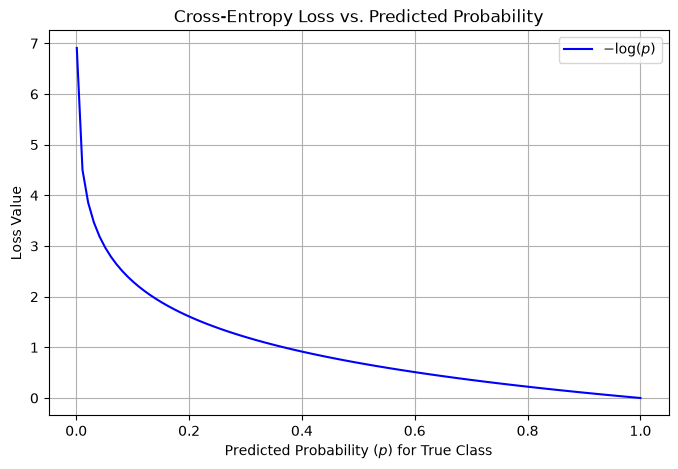

In [8]:
p_vals = np.linspace(0.001, 1.0, 100)
loss_vals = -np.log(p_vals)
plt.figure(figsize=(8, 5))
plt.plot(p_vals, loss_vals, color='blue', label='$-\\log(p)$')
plt.title('Cross-Entropy Loss vs. Predicted Probability')
plt.xlabel('Predicted Probability ($p$) for True Class')
plt.ylabel('Loss Value')
plt.grid(True)
plt.legend()
plt.show()

## 4. Compute loss directly from scores

We can combine softmax and negative log-probability into one expression. Start with

$$p_y=\frac{e^{s_y}}{\sum_j e^{s_j}}, \qquad L=-\log p_y.$$

Substituting $p_y$ and using $\log(a/b)=\log a-\log b$ gives

$$L=-\log\left(\frac{e^{s_y}}{\sum_j e^{s_j}}\right)
=-s_y+\log\left(\sum_j e^{s_j}\right).$$

For numerical stability, subtract the maximum score from every score first:

$$L=-s_y^{shifted}+\log\left(\sum_j e^{s_j^{shifted}}\right).$$

This computes the same loss while avoiding overflow and avoiding the unstable sequence of first producing an extremely tiny probability and then taking its logarithm.

This expression also becomes the starting point for the next gradient notebook. Differentiating its two terms with respect to score $s_j$ gives

$$\frac{\partial L}{\partial s_j}=p_j-\mathbb{1}[j=y].$$

So the stable forward-loss formula and the compact softmax gradient come from the same algebraic form.

### Exercise 4 — One-example softmax loss

Implement the loss using the stable log-sum-exp expression above.

In [9]:
probabilities_one

array([0.09003057, 0.24472847, 0.66524096])

In [10]:
def softmax_loss_one(scores: np.ndarray, correct_label: int) -> float:
    """Return stable cross-entropy loss for one example."""
    if not isinstance(scores, np.ndarray) or scores.ndim != 1 or scores.size == 0:
        raise ValueError("Scores must be a nonempty 1D NumPy array.")
    if not isinstance(correct_label, (int, np.integer)):
        raise TypeError("The correct label must be an integer.")
    if correct_label < 0 or correct_label >= scores.size:
        raise ValueError("The correct label must index scores.")

    # use shifted scores and log-sum-exp.
    shifted_scores = scores - np.max(scores)  # Shift for numerical stability
    log_sum_exp = np.log(np.sum(np.exp(shifted_scores)))
    loss = log_sum_exp - shifted_scores[correct_label]
    return loss


loss_one = softmax_loss_one(scores_one, correct_label=2)
expected_loss_one = -np.log(probabilities_one[2])
assert np.isclose(loss_one, expected_loss_one)
assert np.isclose(
    softmax_loss_one(scores_one + 10_000, 2), expected_loss_one
)
print("Loss:", loss_one)

Loss: 0.4076059644443804


## 5. Vectorized batch softmax

For `scores` with shape `(N, C)`, stability requires subtracting a different maximum from each row. Therefore, compute row maxima with `axis=1, keepdims=True`. The retained dimension gives shape `(N, 1)`, allowing NumPy to broadcast one maximum across the `C` scores in its row.

### Exercise 5 — Implement batch probabilities and loss

Complete both functions without loops. The batch loss is the mean correct-class negative log-probability, but compute it directly from shifted scores with log-sum-exp. Calling `np.log(softmax_probabilities(...))` can still fail if a very small probability underflows to exactly zero.

In [11]:
def softmax_probabilities(scores: np.ndarray) -> np.ndarray:
    """Return stable row-wise softmax probabilities for a score batch."""
    if not isinstance(scores, np.ndarray) or scores.ndim != 2:
        raise ValueError("Scores must be a 2D NumPy array.")
    if scores.shape[0] == 0 or scores.shape[1] == 0:
        raise ValueError("Scores must not be empty.")

    # subtract each row maximum, exponentiate, and normalize each row.
    shifted_scores = scores - np.max(scores, axis=1, keepdims=True)  # Shift for numerical stability
    exp_scores = np.exp(shifted_scores)
    probabilities = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    return probabilities


def softmax_loss(scores: np.ndarray, labels: np.ndarray) -> float:
    """Return mean cross-entropy data loss for a batch."""
    if labels.ndim != 1 or scores.shape[0] != labels.shape[0]:
        raise ValueError("Labels must be 1D and match the batch size.")
    if not np.issubdtype(labels.dtype, np.integer):
        raise TypeError("Labels must contain integers.")
    if np.any((labels < 0) | (labels >= scores.shape[1])):
        raise ValueError("Labels must be valid class indices.")

    # use shifted scores and row-wise log-sum-exp directly.
    shifted_scores = scores - np.max(scores, axis=1, keepdims=True)  # Shift for numerical stability
    log_sum_exp = np.log(np.sum(np.exp(shifted_scores), axis=1))
    correct_class_scores = shifted_scores[np.arange(scores.shape[0]), labels]
    loss = np.mean(log_sum_exp - correct_class_scores)
    return loss


scores_small = np.array([
    [1.0, 2.0, 3.0],
    [2.0, 2.0, 2.0],
    [-1.0, 1.0, 0.0],
])
labels_small = np.array([2, 0, 1])
probabilities_small = softmax_probabilities(scores_small)
batch_loss = softmax_loss(scores_small, labels_small)

assert probabilities_small.shape == scores_small.shape
np.testing.assert_allclose(probabilities_small.sum(axis=1), 1.0)
expected_batch_loss = np.mean([
    softmax_loss_one(scores_small[i], labels_small[i])
    for i in range(len(labels_small))
])
assert np.isclose(batch_loss, expected_batch_loss)
assert np.isfinite(softmax_loss(np.array([[1000.0, 0.0, -1000.0]]), np.array([2])))
print("Probabilities:\n", probabilities_small)
print("Mean loss:", batch_loss)

Probabilities:
 [[0.09003057 0.24472847 0.66524096]
 [0.33333333 0.33333333 0.33333333]
 [0.09003057 0.66524096 0.24472847]]
Mean loss: 0.6379414058522902


In [12]:
scores_small

array([[ 1.,  2.,  3.],
       [ 2.,  2.,  2.],
       [-1.,  1.,  0.]])

In [13]:
scores_small - np.max(scores_small, axis=1, keepdims=True)

array([[-2., -1.,  0.],
       [ 0.,  0.,  0.],
       [-2.,  0., -1.]])

In [14]:
shifted_scores = scores_small - np.max(scores_small, axis=1, keepdims=True)
shifted_scores[np.arange(scores_small.shape[0]), [2, 2, 2]]

array([ 0.,  0., -1.])

In [15]:
np.log(np.sum(np.exp(shifted_scores), axis=1))

array([0.40760596, 1.09861229, 0.40760596])

## 6. Loss invariants and confidence

These experiments distinguish properties of softmax from implementation accidents.

### Exercise 6 — Test four predictions

Use code and short explanations to test:

1. adding a different constant to every score row leaves probabilities and loss unchanged;
2. multiplying all scores by a positive number preserves the predicted class but generally changes probabilities and loss;
3. equal scores produce a uniform distribution and loss $\log C$;
4. making the correct score increasingly larger drives the loss toward zero but never creates the SVM's flat zero-loss region at a finite score separation.

In [16]:
# test row-shift invariance.
row_shifts = rng.normal(size=(scores_small.shape[0], 1))

assert np.allclose(
    softmax_probabilities(scores_small + row_shifts),
    probabilities_small
)
assert np.isclose(
    softmax_loss(scores_small + row_shifts, labels_small),
    batch_loss,
)

# compare predictions, probabilities, and loss after scaling scores.
score_scale = 3.0

scaled_probabilities = softmax_probabilities(scores_small * score_scale)
np.testing.assert_array_equal(
    np.argmax(scaled_probabilities, axis=1),
    np.argmax(probabilities_small, axis=1),
)
assert not np.allclose(scaled_probabilities, probabilities_small)

print("Scaled scores:\n", scores_small * score_scale)
print("Scaled probabilities:\n", scaled_probabilities)
print("Original probabilities:\n", probabilities_small)
print("Scaled loss:", softmax_loss(scores_small * score_scale, labels_small))
print("original loss:", batch_loss)

# verify the uniform-distribution loss for C classes.
num_classes = scores_small.shape[1]

print("Uniform distribution loss for C classes:", np.log(num_classes))
assert np.allclose(
    softmax_loss(np.zeros((5, num_classes)), np.array([0, 1, 2, 0, 1])),
    np.log(num_classes)
)

# calculate loss as the correct score grows.
correct_score_values = np.linspace(0.0, 10.0, 100)
growing_confidence_losses = []

for correct_score in correct_score_values:
    scores = np.array([[correct_score, 0.0, 0.0]])
    loss = softmax_loss(scores, np.array([0]))
    growing_confidence_losses.append(loss)



Scaled scores:
 [[ 3.  6.  9.]
 [ 6.  6.  6.]
 [-3.  3.  0.]]
Scaled probabilities:
 [[0.00235563 0.04731416 0.95033021]
 [0.33333333 0.33333333 0.33333333]
 [0.00235563 0.95033021 0.04731416]]
Original probabilities:
 [[0.09003057 0.24472847 0.66524096]
 [0.33333333 0.33333333 0.33333333]
 [0.09003057 0.66524096 0.24472847]]
Scaled loss: 0.4001679385713688
original loss: 0.6379414058522902
Uniform distribution loss for C classes: 1.0986122886681098


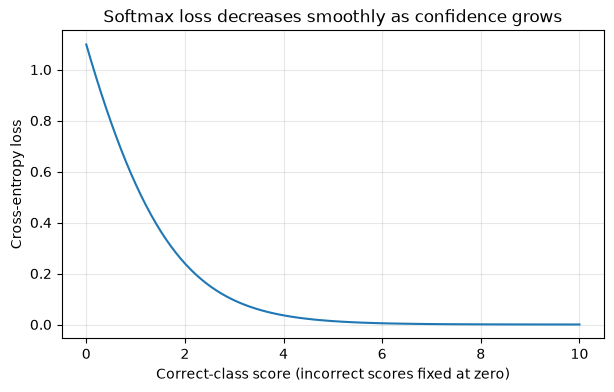

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(correct_score_values, growing_confidence_losses)
ax.set(
    xlabel="Correct-class score (incorrect scores fixed at zero)",
    ylabel="Cross-entropy loss",
    title="Softmax loss decreases smoothly as confidence grows",
)
ax.grid(alpha=0.3)
plt.show()

## 7. Softmax and SVM respond differently

Both losses prefer the correct score to exceed incorrect scores, but they express that preference differently:

- SVM considers each incorrect-class margin separately and becomes exactly zero once all required margins are satisfied.
- Softmax couples all classes through one normalization and continues rewarding greater correct-class probability, although the improvement becomes progressively smaller.

Neither raw softmax probabilities nor their confidence should automatically be interpreted as calibrated real-world probabilities; calibration is a separate empirical property.

### Exercise 7 — Compare losses along one score path

Keep two incorrect scores at zero, vary the correct score, and plot both losses. Use $\Delta=1$ for SVM. Mark or describe where SVM reaches zero and explain why softmax remains positive.

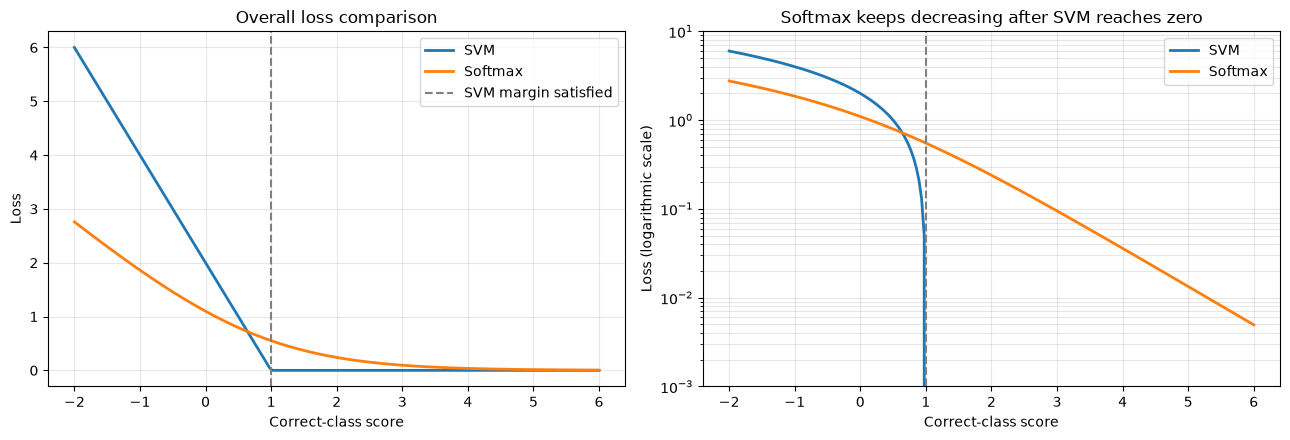

In [18]:
def svm_loss_one_for_comparison(
    scores: np.ndarray, correct_label: int, delta: float = 1.0
) -> float:
    margins = np.maximum(0.0, scores - scores[correct_label] + delta)
    margins[correct_label] = 0.0
    return float(margins.sum())


score_path = np.linspace(-2.0, 6.0, 200)
# calculate both losses when class 0 is correct and its score follows score_path.
svm_losses = np.array([
    svm_loss_one_for_comparison(np.array([score, 0.0, 0.0]), correct_label=0)
    for score in score_path
])
softmax_losses = np.array([
    softmax_loss(np.array([[score, 0.0, 0.0]]), np.array([0]))
    for score in score_path
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(score_path, svm_losses, label="SVM", linewidth=2)
axes[0].plot(score_path, softmax_losses, label="Softmax", linewidth=2)
axes[0].axvline(1.0, color="gray", linestyle="--", label="SVM margin satisfied")
axes[0].set(
    xlabel="Correct-class score",
    ylabel="Loss",
    title="Overall loss comparison",
)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(score_path, svm_losses, label="SVM", linewidth=2)
axes[1].plot(score_path, softmax_losses, label="Softmax", linewidth=2)
axes[1].axvline(1.0, color="gray", linestyle="--")
axes[1].set(
    xlabel="Correct-class score",
    ylabel="Loss (logarithmic scale)",
    title="Softmax keeps decreasing after SVM reaches zero",
    yscale="log",
)
axes[1].set_ylim(1e-3, 10)
axes[1].legend()
axes[1].grid(alpha=0.3, which="both")

fig.tight_layout()
plt.show()

## 8. Near-zero random weights on CIFAR-10

With near-equal scores, softmax probabilities are near $1/C$. The expected initial loss is therefore

$$-\log(1/C) = \log C.$$

For CIFAR-10, this is $\log(10) \approx 2.303$.

In [19]:
dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
NUM_EXAMPLES = 1_000
indices = rng.choice(len(dataset.data), size=NUM_EXAMPLES, replace=False)
X = dataset.data[indices].reshape(NUM_EXAMPLES, -1).astype(np.float64) / 255.0
y = np.asarray(dataset.targets, dtype=np.int64)[indices]
X -= X.mean(axis=0, keepdims=True)

num_classes = 10
W_random = rng.normal(0.0, 1e-5, size=(num_classes, X.shape[1]))
b_random = np.zeros(num_classes)
scores_random = X @ W_random.T + b_random
initial_loss = softmax_loss(scores_random, y)

print("Initial softmax loss:", initial_loss)
print("log(C):", np.log(num_classes))
assert np.isclose(initial_loss, np.log(num_classes), atol=0.02)

Initial softmax loss: 2.302612285594655
log(C): 2.302585092994046


## Reflection

Add a Markdown cell answering:

1. Why are raw class scores not probabilities?
2. What does exponentiation contribute, and what does normalization contribute?
3. Why does subtracting the maximum score not change softmax probabilities?
4. Why is cross-entropy zero when the correct-class probability is one?
5. Why does confidently assigning low probability to the correct class produce a large loss?
6. Why do equal scores produce loss $\log C$?
7. What changes and what remains unchanged when all scores are multiplied by a positive constant?
8. How do SVM and softmax losses respond differently once the correct class has the highest score?
9. Why is numerical stability part of correctness rather than merely an optimization?

Next we will derive the compact softmax score gradient $dS = (P-Y)/N$, propagate it to `W` and `b`, and verify it numerically.

1. Raw scores can be any real numbers, including negative values. They are not restricted to `[0, 1]`, and their sum is not necessarily `1`, so they do not form a probability distribution.

2. Exponentiation makes every value positive and gives higher scores relatively more weight. Normalization divides the exponentials by their sum, making the resulting probabilities sum to `1`.

3. Adding or subtracting the same constant $a$ from every score multiplies every exponential by the same factor $e^a$. That factor appears in both the numerator and denominator and cancels, so the probabilities do not change.

4. If the correct-class probability is `1`, its cross-entropy loss is $-\log(1)=0$. This is the minimum possible loss.

5. Cross-entropy is $-\log(p_y)$. As the probability assigned to the correct class approaches zero, $\log(p_y)$ becomes a large negative number, so $-\log(p_y)$ becomes a large positive loss.

6. Equal scores produce equal exponentials, so each of the $C$ classes receives probability $1/C$. The correct-class loss is $-\log(1/C)=\log C$. There is no additional division by $C$.

7. Multiplying all scores by a positive constant preserves their ordering, so the predicted class remains unchanged. It generally changes the probability distribution and loss: scaling by a value greater than one makes the distribution sharper, while scaling by a value between zero and one makes it flatter.

8. Having the highest correct-class score is not by itself enough for zero SVM loss. SVM reaches zero once the correct score exceeds every incorrect score by at least the margin $\Delta$. Beyond that point it stays zero. Softmax loss remains positive at every finite score separation and continues decreasing smoothly as the correct-class probability approaches one.

9. Numerical stability affects whether the computed result is mathematically meaningful. Directly exponentiating large scores can overflow to `inf`; very negative values can underflow to `0`; subsequent division or logarithms can produce `NaN` or `inf`. Score shifting computes the same mathematical softmax while keeping intermediate values representable, so it is part of a correct finite-precision implementation.